# Low-thrust transfers via indirect methods

In this notebook we show how to solve the minimum mass Optimal Control Problem (OCP) for a low-thrust interplanetary transfer employing an indirect method.

Indirect methods are basically following the same template: starting from the dynamics an augmented system of ODE is built applying Pontryagin maximum (minimum, in our case) principle. A Two Point Boundary Value Problem is hence defined on the derived augmented system and solved by means of single or multiple shooting.

In this notebook we guide, step-by-step, the reader in the application of such a method in a widely encountered case in space flight mechanics, and eventually use `pykep` native tools to quickly skip the tedious parts.

In [1]:
import pykep as pk
import numpy as np
import heyoka as hy
import pygmo as pg
import pygmo_plugins_nonfree as ppnf

from matplotlib import pyplot as plt

## Manual construction of the TPBVP
We consider the dynamics:

$$
\left\{
\begin{array}{l}
\dot{\mathbf r}  = \mathbf v \\
\dot{\mathbf v} = -\frac{mu}{r^3}\mathbf r + c_1 \frac um \hat{\mathbf i}\\
\dot{m} = - c_2 u
\end{array}
\right.
$$
where $c_1=T_{max}$ is the maximum thrust that the spacecarft propulsion can deliver, while $c_2 = \frac{T_{max}}{I_{sp} g_0}$.

We also introduce as many auxiliary functions $\mathbf \lambda$ (the co-states) are there are state variables. Using `heyoka` as a symbolic manipulator, let us introduce symbols for all the time dependent quantities:

In [2]:
# The state
x, y, z, vx, vy, vz, m = hy.make_vars("x", "y", "z", "vx", "vy", "vz", "m")
# The costate
lx, ly, lz, lvx, lvy, lvz, lm = hy.make_vars(
    "lx", "ly", "lz", "lvx", "lvy", "lvz", "lm"
)
# The controls
u, ix, iy, iz = hy.make_vars("u", "ix", "iy", "iz")

As to write comfortably the various developments, we introduce some useful expressions and regroup some of our variable into 3D vectors:

In [3]:
# Useful expressions
r3 = (x**2 + y**2 + z**2) ** (1.5)
lv_norm = hy.sqrt(lvx**2 + lvy**2 + lvz**2)
rho = 1 - hy.par[1] * lv_norm / m / hy.par[4] - hy.par[2] * lm / hy.par[4]

# Vectors for convenience of math manipulation
lr = np.array([lx, ly, lz])
lv = np.array([lvx, lvy, lvz])
r = np.array([x, y, z])
v = np.array([vx, vy, vz])
i_vers = np.array([ix, iy, iz])

Note that various constants of our problem are considered as heyoka parameters in the following order: $[\mu, c_1, c_2, \epsilon, \lambda_0]$, $c_1 = T_{max}$, $c_2 = \frac{T_{max}}{I_{sp}g_0}$

The dynamics can then be written as:

In [4]:
#Dynamics
fr = v
fv = hy.par[1] * u / m * i_vers - (hy.par[0] / r3) * r
fm = -hy.par[2] * u

We introduce the Hamiltonian ($\mathbf x$ is the whole state, $\mathbf \lambda$ is the whole co-state, and $\mathbf u$ represent are all the controls), 

$$
\mathcal H(\mathbf x, \mathbf \lambda, \mathbf u) = \mathbf \lambda_r \cdot \mathbf f_r + \mathbf \lambda_v \cdot \mathbf f_v + \lambda_m  f_m + \lambda_0 \left(u + \epsilon\log(u(1-u))\right)
$$

In [5]:
# Hamiltonian
H_full = (
      lr @ fr
    + lv @ fv
    + lm * fm
    + hy.par[4] * (u - hy.par[3] * hy.log(u*(1 - u)))
)

And write the resulting Hamiltonian system:

$$
\left\{
\begin{array}{l}
\dot{\mathbf x} = \frac{\partial \mathcal H}{\partial \mathbf \lambda} \\
\dot{\mathbf \lambda} = - \frac{\partial \mathcal H}{\partial \mathbf x} \\
\end{array}\right.
$$

In [6]:
# Augmented equations of motion
rhs = [
    hy.diff(H_full, var)
    for var in [lx, ly, lz, lvx, lvy, lvz, lm, x, y, z, vx, vy, vz, m]
]
for j in range(7, 14):
    rhs[j] = -rhs[j]

The minimum principle from Pontryagin requires to find the mimimum in the admissible control space of the Hamiltonian:

$$
\mathbf u^* = \argmin_{\mathbf u \in \mathcal U} \mathcal H(\mathbf x, \mathbf \lambda, \mathbf u)
$$

which, in our case, results in:

In [7]:
# We apply Pontryagin minimum principle (primer vector and u^* = 2eps / (rho + 2eps + sqrt(rho^2+4*eps^2)))
argmin_H_full = {
    ix: -lvx / lv_norm,
    iy: -lvy / lv_norm,
    iz: -lvz / lv_norm,
    u: 2
    * hy.par[3]
    / (rho + 2 * hy.par[3] + hy.sqrt(rho * rho + 4 * hy.par[3] * hy.par[3])),
}

Thanks to the above relations, the control is now a continuous differentiable function of the states and costates and thus the dynamics as well as the Hamiltonian can be reworked: 

In [8]:
rhs = hy.subs(rhs, argmin_H_full)

# We also build the Hamiltonian as a function of the state / co-state only
# (i.e. no longer of controls now solved thanks to the minimum principle)
H = hy.subs(H_full, argmin_H_full)

The following code block thus instantiate the heyoka integrator as well as other convenience functions for later analysis.

In [9]:
# We compile the Hamiltonian into a C function (to be called with pars = [mu, c1, c2, eps, l0])
H_func = hy.cfunc([H], [x, y, z, vx, vy, vz, m, lx, ly, lz, lvx, lvy, lvz, lm])
# We compile the thrust direction
u_func = hy.cfunc(
    [argmin_H_full[u]], [x, y, z, vx, vy, vz, m, lx, ly, lz, lvx, lvy, lvz, lm]
)
# We compile the SF
rho_func = hy.cfunc([rho], [x, y, z, vx, vy, vz, m, lx, ly, lz, lvx, lvy, lvz, lm])
# We compile also the thrust direction
i_vers_func = hy.cfunc(
    [argmin_H_full[ix], argmin_H_full[iy], argmin_H_full[iz]], [lvx, lvy, lvz]
)
# We assemble the Taylor adaptive integrator
full_state = [x, y, z, vx, vy, vz, m, lx, ly, lz, lvx, lvy, lvz, lm]
sys = [(var, dvar) for var, dvar in zip(full_state, rhs)]
ta = hy.taylor_adaptive(sys, state=[1.0] * 14)

## Constructing the TPBVP using pykep

For the specific case outlined above pykep offers a convenient series of pre-assembled functions and objects which basically construct the same useful objects as above:

In [10]:
# The Taylor integrator
ta = pk.ta.get_pc(1e-16)
# The Hamiltonian
H_func = pk.ta.get_pc_H_cfunc()
# The switching function
SF_func = pk.ta.get_pc_SF_cfunc()
# The magnitude of the throttle
u_func = pk.ta.get_pc_u_cfunc()
# The thrust direction
i_vers_func = pk.ta.get_pc_i_vers_cfunc()

## Solving in single shooting

We use, as a test case, a simple transfer between two orbits at 1AU. The transfer is simple enough to allow fast convergence and to directly go for a mass optimal trajectory, without using continuation, so that: $\epsilon << 1$.

For convenience and comparison, we also leave a second case commented out where, insted, homotopy would be needed. This case has an $\epsilon$ of $0.1$, which is not mass optimal. Using lower values directly will result in no convergence.

In [11]:
# Testcase 1 (easy, no homotopy)
posvel0 = [
    [34110913367.783306, -139910016918.87585, -14037825669.025244],
    [29090.9902134693, 10000.390168313803, 1003.3858682643288],
]
posvelf = [
    [-159018773159.22266, -18832495968.945133, 15781467087.350443],
    [2781.182556622003, -28898.40730995848, -483.4533989771214],
]
tof = 250
mu = pk.MU_SUN
eps = 1e-4

m0 = 1500
T_max = 0.6
I_sp = 3000

## Testcase 2 (less easy, homotopy needed) [Earth-Mars with]
#posvel0 = [[-125036811000.422, -83670919168.87277, 2610252.8064399767],
# [16081.829029183446, -24868.923007449284, 0.7758272135425942]]
#posvelf = [[-169327023332.1986, -161931354587.78766, 763967345.9733696],
# [17656.297796509956, -15438.116653052988, -756.9165272457421]]
#tof = 550
#mu = pk.MU_SUN
#eps = 1e-1


We instantiate the shooting method using the udp_p provided by `pykep`:

In [12]:
udp_p = pk.trajopt.pontryagin_cartesian(
    posvel0=posvel0,
    posvelf=posvelf,
    tof=tof,
    mu=mu,
    eps=eps,
    T_max=T_max,
    Isp=I_sp,
    m0=m0,
    L=pk.AU,
    TIME=pk.YEAR2DAY * pk.DAY2SEC,
    MASS=m0,
    with_gradient=True,
)
prob = pg.problem(udp_p)
prob.c_tol = 1e-6

To solve this problem, we can use both SPQ methods and interior point methods. In this notebook, we make use of the widely available IPOPT solver, which has the great advantage to be also be fully open-source.

In [13]:
ip = pg.ipopt()
ip.set_numeric_option("tol", 1E-9) # Change the relative convergence tolerance
ip.set_integer_option("max_iter", 500) # Change the maximum iterations
ip.set_integer_option("print_level", 0) # Makes Ipopt unverbose
ip.set_string_option("nlp_scaling_method", "none") # Removes any scaling made in auto mode
ip.set_string_option("mu_strategy", "adaptive") # Alternative is to tune the initial mu value
algo = pg.algorithm(ip)

To solve the problem we use a loop, since this is in genral a good practice. In this specific case convergence is immediate and the loop would not be strictly necessary.

In [14]:
masses_p = []
xs_p = []
for i in range(30):
    pop_p = pg.population(prob, 1)
    pop_p = algo.evolve(pop_p)
    if(prob.feasibility_f(pop_p.champion_f)):
        print(". Success!!", end="")
        udp_p.fitness(pop_p.champion_x)
        xs_p.append(pop_p.champion_x)
        masses_p.append(udp_p.ta.state[6])
        break
    else:
        print("x", end ="")
print(f"\nFinal mass is: {masses_p[0]*udp_p.MASS} \n")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

. Success!!
Final mass is: 1259.8614051421155 



Let us plot what we found ...

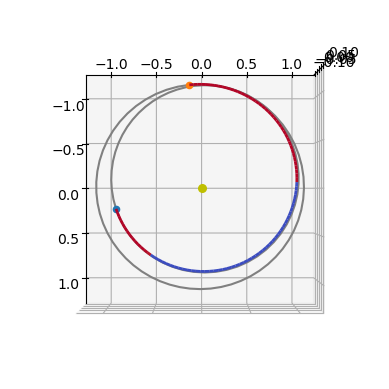

In [15]:
ax3D = udp_p.plot_trajectory(pop_p.champion_x)
ax3D.view_init(90,0)

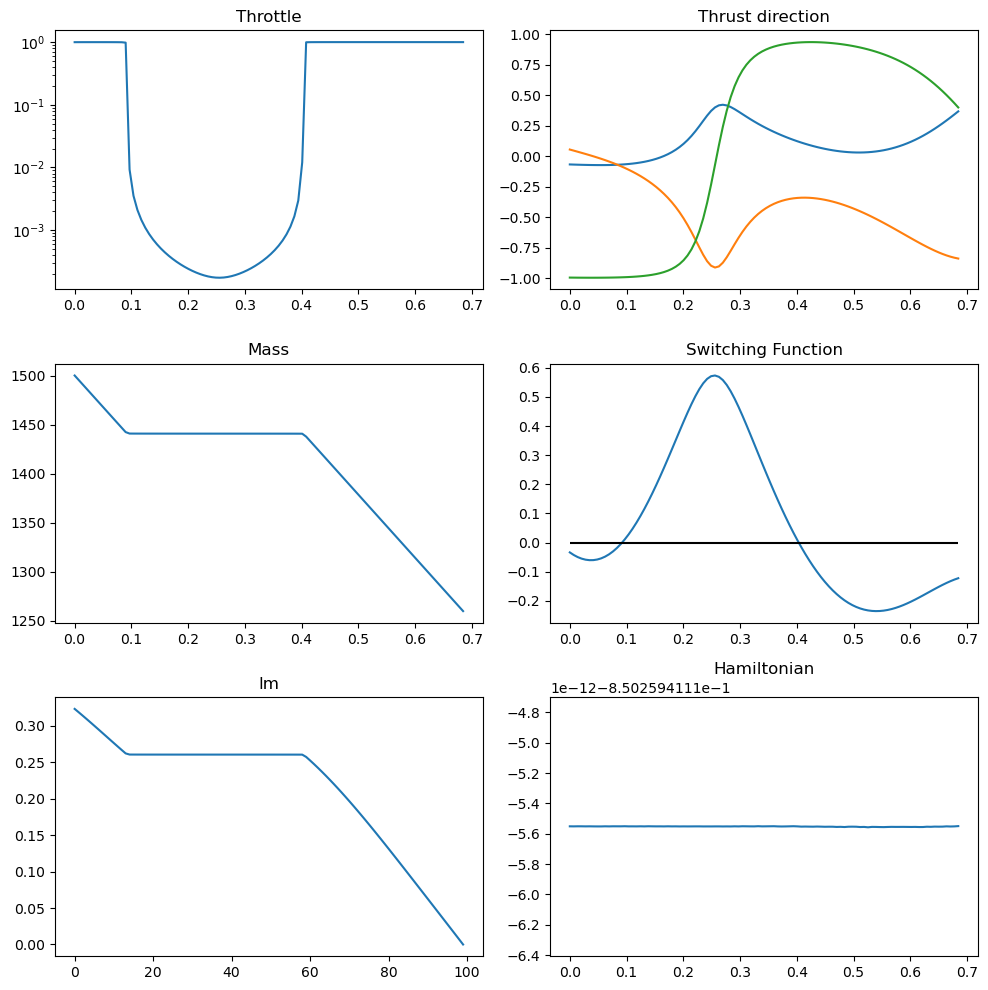

In [16]:
udp_p.plot_misc(pop_p.champion_x);

# Planet to planet low-thrust


We start defining the problem data.

In [17]:
# Problem data
mu = pk.MU_SUN
max_thrust = T_max
isp = I_sp

# Define initial and target
p1 = pk.planet(pk.udpla.keplerian(elem=pk.ic2par(posvel0,pk.MU_SUN), when=pk.epoch(0), mu_central_body=mu))
p2 = pk.planet(pk.udpla.keplerian(elem=pk.ic2par(posvelf,pk.MU_SUN), when=pk.epoch(tof), mu_central_body=mu))

# Initial state
ms = m0

# Number of segments
nseg = 10

In [18]:
# With Gradient
udp_sf_g = pk.trajopt.direct_pl2pl(
        pls=p1,
        plf=p2,
        ms=ms,
        mu=mu,
        max_thrust=max_thrust,
        isp=I_sp,
        t0_bounds=[0.0, 0.0],
        tof_bounds=[tof, tof],
        mf_bounds=[ms*0.5, ms],
        vinfs=0.,
        vinff=0.,
        nseg=nseg,
        cut=0.6,
        mass_scaling=ms,
        r_scaling=pk.AU,
        v_scaling=pk.EARTH_VELOCITY,
        with_gradient=False,
)

In [19]:
# We need to generste a random chromosomes compatible with the udp_p where to test the gradient.
prob_sf_g = pg.problem(udp_sf_g)
pop_sf_g = pg.population(prob_sf_g, 1)

In [20]:
# %%timeit
# udp_sf_g.gradient(pop_sf_g.champion_x)

In [21]:
# %%timeit
# pg.estimate_gradient(udp_sf_g.fitness, pop_sf_g.champion_x)

In [22]:
# %%timeit
# pg.estimate_gradient_h(udp_sf_g.fitness, pop_sf_g.champion_x)

## Solving the low-thrust transfer

We define (again) the optimization problem, and set a tolerance for *pagmo* to be able to judge the relative value of two individuals. 

:::{note}
This tolerance has a different role from the numerical tolerance set in the particular algorithm chosen to solve the problem and is only used by the *pagmo* machinery to decide outside the optimizer whether the new proposed indivdual is better than what was the previous *champion*.

In [23]:
prob_sf_g = pg.problem(udp_sf_g)
prob_sf_g.c_tol = 1e-6

In [24]:
snopt72 = "/Users/harry.holt/opt/libsnopt7_c.dylib"
uda = ppnf.snopt7(library=snopt72, minor_version=2, screen_output=False)
uda.set_integer_option("Major iterations limit", 2000)
uda.set_integer_option("Iterations limit", 20000)
# uda.set_numeric_option("Major optimality tolerance", 1e-3)
uda.set_numeric_option("Major optimality tolerance", 1e-9)
uda.set_numeric_option("Major feasibility tolerance", 1e-11)

#uda = pg.nlopt("slsqp")
algo = pg.algorithm(uda)

We solve the problem from random initial guess ten times and only save the result if a feasible solution is found (as defined by the criterias above)

In [25]:
masses_sf = []
xs_sf = []
for i in range(10):
    pop_sf_g = pg.population(prob_sf_g, 1)
    pop_sf_g = algo.evolve(pop_sf_g)
    if(prob_sf_g.feasibility_f(pop_sf_g.champion_f)):
        print(".", end="")
        masses_sf.append(pop_sf_g.champion_x[1])
        xs_sf.append(pop_sf_g.champion_x)
    else:
        print("x", end ="")
print("\nBest mass is: ", np.max(masses_sf))
print("Worst mass is: ", np.min(masses_sf))
best_idx = np.argmax(masses_sf)

.x.xxx.x.x
Best mass is:  1259.8267778921124
Worst mass is:  1259.8264107584857


In [26]:
udp_sf_g.pretty(xs_sf[best_idx])


Low-thrust NEP transfer
Departure: unknown UDPLA
Arrival: unknown UDPLA

Launch epoch: 0.00000 MJD2000, a.k.a. 2000-01-01T00:00:00.000000
Arrival epoch: 250.00000 MJD2000, a.k.a. 2000-09-07T00:00:00.000000
Time of flight (days): 250.00000 

Launch DV (km/s) 0.00000000 - [0.0,0.0,0.0]
Arrival DV (km/s) 0.00000000 - [0.0,0.0,0.0]
Final mass (kg): 1259.8267778921124

Details on the low-thrust leg: 
Number of segments: 10
Number of fwd segments: 6
Number of bck segments: 4
Maximum thrust: 0.6
Central body gravitational parameter: 1.3271244004127942e+20
Specific impulse: 3000

Time of flight: 21600000
Initial mass: 1500
Final mass: 1259.8267778921124
State at departure: [[34110913367.783382, -139910016918.8758, -14037825669.025322], [29090.99021346929, 10000.390168313817, 1003.385868264337]]
State at arrival: [[-159018773159.22263, -18832495968.94509, 15781467087.350529], [2781.1825566219954, -28898.407309958482, -483.45339897712336]]
Throttles values: [-0.08203898768730224, 0.017361648644

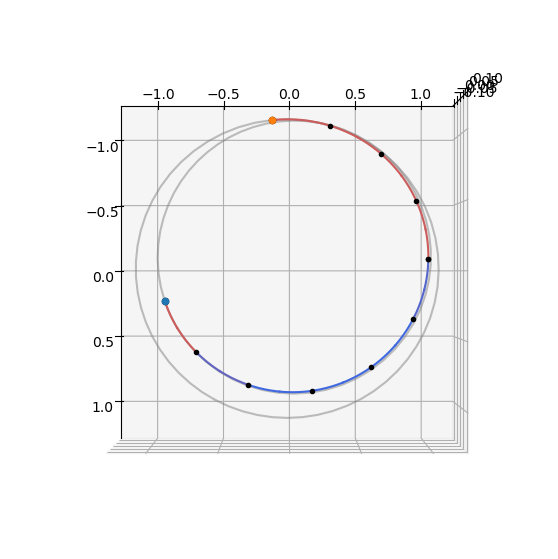

In [27]:
ax = udp_sf_g.plot(xs_sf[best_idx], show_gridpoints=True)
ax.view_init(90, 0)
# plt.show()

## Comparison

In [28]:
print(f"Pontryagin final mass is: {masses_p[0]*udp_p.MASS} kg {masses_p[0]}")
print(f"Sims-Flanagan final mass is: {np.max(masses_sf)} kg {np.max(masses_sf)/m0}")


Pontryagin final mass is: 1259.8614051421155 kg 0.8399076034280769
Sims-Flanagan final mass is: 1259.8267778921124 kg 0.8398845185947417
